In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [2]:
x = np.array([1,2,3,4])
y = np.array([2,2.8,3.6,4.5])

In [4]:
n = len(x)
# init paramatars
w = 0
b = 0
'''
np.random.seed(42)
w = np.random.rand()
b = np.random.rand()
'''
learning_rate = 0.01
epochs = 10000
cost_value = []
print(f"initial w : {w}")
print(f"initial b : {b}")
print(f"initial learning_rate : {learning_rate}")
print(f"initial epochs : {epochs}")
print("Training.....................")

initial w : 0
initial b : 0
initial learning_rate : 0.01
initial epochs : 10000
Training.....................


In [5]:
#========================
#Gradient descent
#========================

for i in range(epochs):
    y_hat = w * x + b
    error = y_hat - y
    d_w = np.mean(error * x)
    d_b = np.mean(error * 1)
    
    #update parameters
    w -= learning_rate * d_w
    b -= learning_rate * d_b
    
    #new line predict
    y_hat = w * x + b 
    
    #cost = MSE
    cost = np.mean((y_hat - y)**2)
    cost_value.append(cost)
    
    if (i+1) % 100 == 0 or i ==0 :
        print(f"Epoch {i+1}:"
              f"cost = {cost},"
              f"w = {w}, "
              f"b = {b} ")
    

Epoch 1:cost = 9.4761088125,w = 0.091, b = 0.03225 
Epoch 100:cost = 0.07561617368683658,w = 1.0575418455176155, b = 0.48041277301696655 
Epoch 200:cost = 0.05623338544242691,w = 1.0260387078113054, b = 0.5736221969706309 
Epoch 300:cost = 0.04186894802433068,w = 0.9987646244005063, b = 0.6538114239602598 
Epoch 400:cost = 0.031223408807800754,w = 0.9752850537827834, b = 0.7228442248478275 
Epoch 500:cost = 0.023333959196083193,w = 0.9550721051704398, b = 0.7822727586702111 
Epoch 600:cost = 0.017487058075360058,w = 0.9376713060598337, b = 0.8334332300251728 
Epoch 700:cost = 0.013153897411688454,w = 0.9226914129480115, b = 0.8774759425222467 
Epoch 800:cost = 0.009942575559392756,w = 0.9097956145300619, b = 0.9153911624708949 
Epoch 900:cost = 0.007562652717968797,w = 0.8986939587575554, b = 0.9480313842521912 
Epoch 1000:cost = 0.005798882846355757,w = 0.8891368334911053, b = 0.9761304979953049 
Epoch 1100:cost = 0.004491746284672753,w = 0.8809093541645698, b = 1.000320290529155 
Epo

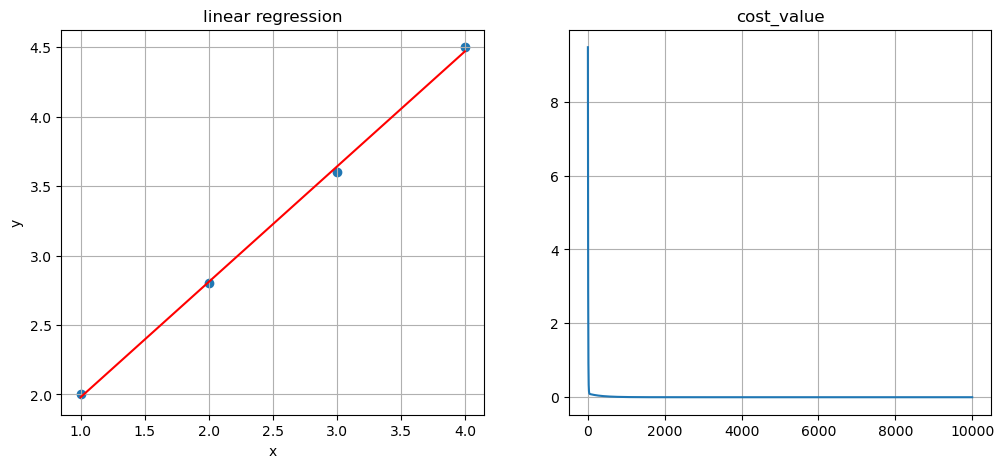

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(x, y)
plt.plot(x, w*x+b, 'r-')
plt.title("linear regression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()


plt.subplot(1,2,2)
plt.plot(cost_value)
plt.title("cost_value")
plt.grid()


In [7]:
data = pd.read_csv('Salary_Data.csv')

In [8]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


/home/sandosa/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 300x400 with 0 Axes>

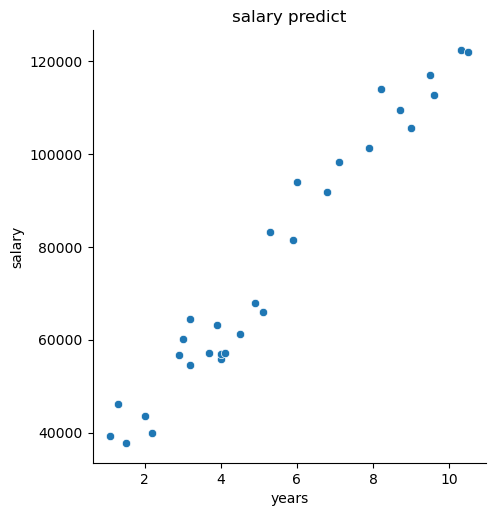

In [9]:
plt.figure(figsize=(3,4))
sns.pairplot(data, x_vars=["YearsExperience"], y_vars=["Salary"],
             size=5, kind="scatter")
plt.xlabel("years")
plt.ylabel("salary")
plt.title("salary predict")
plt.show()

In [10]:
x = data.iloc[: , :-1]
y = data.iloc[: , 1]

In [11]:
x.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size = 0.8,random_state=10)

In [13]:
y_train

13     57081.0
27    112635.0
12     56957.0
1      46205.0
19     93940.0
14     61111.0
18     81363.0
6      60150.0
11     55794.0
23    113812.0
24    109431.0
28    122391.0
22    101302.0
10     63218.0
26    116969.0
29    121872.0
8      64445.0
25    105582.0
16     66029.0
17     83088.0
0      39343.0
15     67938.0
4      39891.0
9      57189.0
Name: Salary, dtype: float64

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
y_hat_train = lin_reg.predict(x_train)

Text(0, 0.5, 'salary')

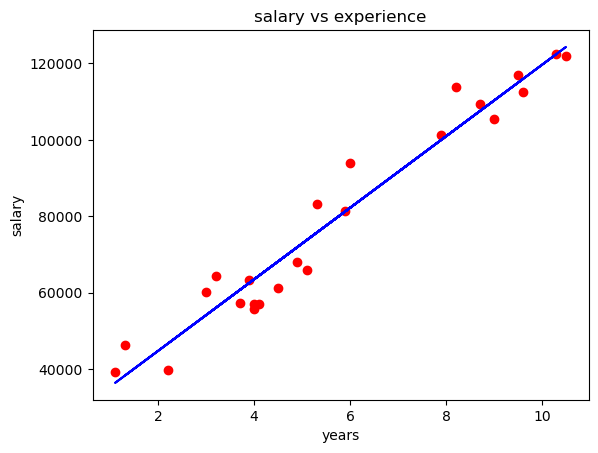

In [15]:
plt.scatter(x_train, y_train, color= 'red')
plt.plot(x_train, y_hat_train, color = "blue")
plt.title("salary vs experience")
plt.xlabel("years")
plt.ylabel("salary")

In [16]:
y_hat_test = lin_reg.predict(x_test)
y_hat_test

array([89715.76498848, 56031.05821174, 53223.99931368, 40124.39112273,
       44802.8226195 , 92522.82388655])

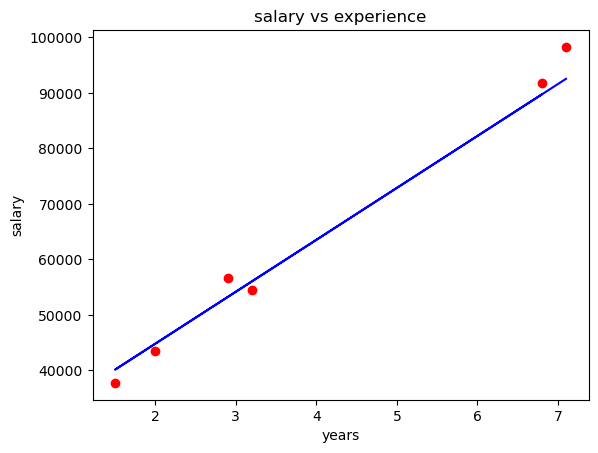

In [17]:
plt.scatter(x_test, y_test, color= 'red')
plt.plot(x_test, y_hat_test, color = "blue")
plt.title("salary vs experience")
plt.xlabel("years")
plt.ylabel("salary")
plt.show()

In [18]:
#calc mean squre error
mse = mean_squared_error(y_test, y_hat_test)
rmse = root_mean_squared_error(y_test, y_hat_test)
print(mse)
print(rmse)
r2 = r2_score(y_test, y_hat_test)
print(r2)


9785570.138914311
3128.1895944642342
0.9816423482070253


In [19]:
bais=lin_reg.intercept_

In [20]:
W=lin_reg.coef_

In [21]:
new_sal = W * 10 + bais
new_sal

array([119657.72656781])

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
#data 
x = np.array([[1],[2],[3],[4]])
y = np.array([2,4,6,8])

#linear
lin_reg = LinearRegression()
lin_reg.fit(x,y)
lin_reg.predict(x) # wx+b